# Viewing Results from Simulation Runs

This notebook provides a few example functions to view and interact with the images generated from the [CT_dataset_pipeline.py](../CT_dataset_pipeline.py).

To begin, locate the `metadata.csv` output by the simulation run specified by the `base_dir` variable in [CT_dataset_pipeline.py](../CT_dataset_pipeline.py), using Pandas this metadata file enables quickly filtering and working with the images to select the examples of interest.

In [2]:
!ls /gpfs_projects/brandon.nelson/pedsilicoICH/pedsilicoICH_10-27-2024_12-43/

case_000  case_012  case_026  case_040	case_054  case_068  case_081  case_094
case_001  case_013  case_027  case_041	case_055  case_069  case_082  case_096
case_002  case_014  case_028  case_042	case_056  case_070  case_083  case_097
case_003  case_016  case_030  case_043	case_058  case_071  case_084  case_098
case_004  case_018  case_031  case_044	case_059  case_072  case_085  case_099
case_005  case_019  case_032  case_045	case_060  case_073  case_086
case_006  case_020  case_033  case_046	case_061  case_074  case_087
case_007  case_021  case_034  case_048	case_062  case_075  case_089
case_008  case_022  case_035  case_049	case_063  case_076  case_090
case_009  case_023  case_036  case_051	case_064  case_078  case_091
case_010  case_024  case_038  case_052	case_065  case_079  case_092
case_011  case_025  case_039  case_053	case_067  case_080  case_093


In [3]:
from pathlib import Path

import pandas as pd
import numpy as np
study_name = 'pedsilicoICH_10-27-2024_12-43'
base_dir = Path('/gpfs_projects/brandon.nelson/pedsilicoICH') / study_name
metadata = pd.concat([pd.read_csv(o) for o in base_dir.rglob('*.csv')], ignore_index=True).sort_values(by=['name', 'image file']).reset_index(drop=True)
metadata.loc[~metadata.intensity.isna(), 'lesion type'] = metadata[~metadata.intensity.isna()]['lesion type'].apply(lambda x: x.split("['")[-1].split("']")[0])
metadata.loc[~metadata.intensity.isna(), 'intensity'] = metadata[~metadata.intensity.isna()]['intensity'].apply(lambda x: float(x.split('[')[-1].split(']')[0])).astype(int)
metadata['image file']=metadata['image file'].apply(lambda x: base_dir / str(x.split(study_name+'/')[-1]))
metadata.loc[~metadata['mask file'].isna(), 'mask file']=metadata.loc[~metadata['mask file'].isna(), 'mask file'].apply(lambda x: base_dir / str(x.split(study_name+'/')[-1]))
metadata

,name,age,intensity,center x,center y,center z,lesion type,mass effect,lesion volume [mL],mA,kVp,views,fov [mm],kernel,image file,mask file
0,case_000,12.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,350,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...
1,case_000,12.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,350,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...
2,case_000,12.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,350,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...
3,case_000,12.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,350,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...
4,case_000,12.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,350,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1965,case_099,6.5,NaN,NaN,NaN,NaN,NaN,NaN,0.0,300,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...
1966,case_099,6.5,NaN,NaN,NaN,NaN,NaN,NaN,0.0,300,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...
1967,case_099,6.5,NaN,NaN,NaN,NaN,NaN,NaN,0.0,300,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...
1968,case_099,6.5,NaN,NaN,NaN,NaN,NaN,NaN,0.0,300,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...


In [4]:
for n in metadata['name'].unique():
    metadata.loc[metadata['name'] == n, 'slice'] = list(range(len( metadata[metadata['name'] == n])))
metadata['slice'] = metadata['slice'].astype(int)

In [5]:
metadata[~metadata.name.duplicated()]

,name,age,intensity,center x,center y,center z,lesion type,mass effect,lesion volume [mL],mA,kVp,views,fov [mm],kernel,image file,mask file,slice
0,case_000,12.00,NaN,NaN,NaN,NaN,NaN,NaN,0.0,350,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,0
23,case_001,6.50,NaN,NaN,NaN,NaN,NaN,NaN,0.0,300,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,NaN,0
45,case_002,12.00,NaN,NaN,NaN,NaN,NaN,NaN,0.0,300,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,NaN,0
68,case_003,15.75,NaN,NaN,NaN,NaN,NaN,NaN,0.0,300,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,NaN,0
91,case_004,12.00,NaN,NaN,NaN,NaN,NaN,NaN,0.0,350,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1859,case_094,12.00,NaN,NaN,NaN,NaN,NaN,NaN,0.0,350,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,0
1882,case_096,6.50,NaN,NaN,NaN,NaN,NaN,NaN,0.0,300,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,0
1904,case_097,10.50,NaN,NaN,NaN,NaN,NaN,NaN,0.0,350,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,0
1925,case_098,11.50,NaN,NaN,NaN,NaN,NaN,NaN,0.0,350,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,NaN,0


In [6]:
metadata[metadata.name=='case_000']['lesion volume [mL]'].sum()

np.float64(0.1783482730388641)

In [7]:
metadata[metadata.name=='case_001']['lesion volume [mL]'].sum()

np.float64(0.0)

In [8]:
metadata[(metadata['lesion volume [mL]']>0)]

,name,age,intensity,center x,center y,center z,lesion type,mass effect,lesion volume [mL],mA,kVp,views,fov [mm],kernel,image file,mask file,slice
10,case_000,12.0,43,172.0,305.0,10.0,round,1.000000,0.157859,350,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,10
11,case_000,12.0,43,172.0,305.0,10.0,round,1.000000,0.020489,350,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,11
103,case_004,12.0,60,267.0,155.0,14.0,subdural,0.000000,0.704546,350,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,12
104,case_004,12.0,60,267.0,155.0,14.0,subdural,0.000000,0.686268,350,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,13
105,case_004,12.0,60,267.0,155.0,14.0,subdural,0.000000,0.765896,350,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1921,case_097,10.5,52,296.0,206.0,17.0,epidural,0.000000,0.922359,350,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,17
1922,case_097,10.5,52,296.0,206.0,17.0,epidural,0.000000,0.625732,350,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,18
1923,case_097,10.5,52,296.0,206.0,17.0,epidural,0.000000,0.223052,350,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,19
1957,case_099,6.5,61,254.0,189.0,9.0,round,0.666667,0.066822,300,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,9


## Interactive Viewing using IPywidgets

In [9]:
from VITools import read_dicom
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

from utils import display_settings, browse_studies, study_viewer

In [10]:
study_viewer(metadata)

interactive(children=(Dropdown(description='name', options=('case_000', 'case_001', 'case_002', 'case_003', 'c…

In [11]:
metadata[metadata.name == 'case_007']

,name,age,intensity,center x,center y,center z,lesion type,mass effect,lesion volume [mL],mA,kVp,views,fov [mm],kernel,image file,mask file,slice
159,case_007,11.5,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,300,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,0
160,case_007,11.5,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,300,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,1
161,case_007,11.5,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,300,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,2
162,case_007,11.5,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,300,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,3
163,case_007,11.5,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,300,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,4
164,case_007,11.5,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,300,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,5
165,case_007,11.5,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,300,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,6
166,case_007,11.5,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,300,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,7
167,case_007,11.5,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,300,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,8
168,case_007,11.5,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,300,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,9


## Viewing the ground truth ICH segmentation masks

The `mask file` column contains the file location containing the ICH mask associated with each image. 

In [12]:
from utils import load_vol

You can filter by `name` to get the intensity and radius of the lesion (it's a sphere in this instance)

Here's an example of how to get the lesion center coordinates from the mask (note the current `center x`, `center y`, `center z` values in `metadata.csv` refer to the coordinates in object space which don't necesarily equal the coordinates in the reconstructed image space due to the effects of the selected reconstructed field of view and magnification.

In [13]:
from utils import get_lesion_coords

With these coordinates we can center the displayed image at the z slice centered about the lesion.

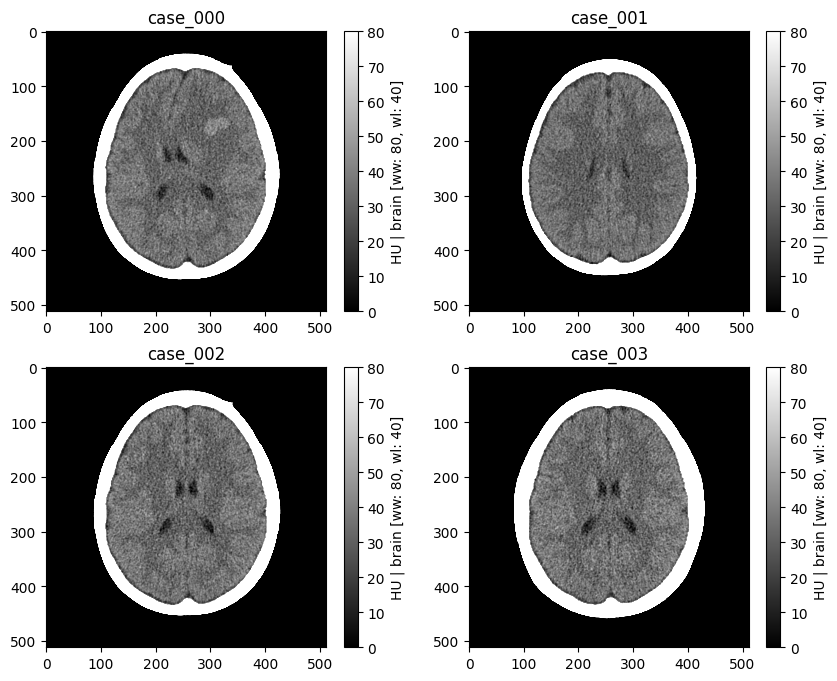

In [23]:
f, axs = plt.subplots(2,2, figsize=(10,8))
for case, ax in zip(metadata['name'].unique(), axs.flatten()):
    if metadata[metadata['name'] == case]['mask file'].isna().iloc[0]:
        z = 10
    else:
        z, x, y = get_lesion_coords(load_vol(metadata[metadata['name'] == case]['mask file']))
    browse_studies(metadata, case, slice_idx=z, f=f, ax=ax, display='brain')

### Highlighting the lesion location with a bounding box

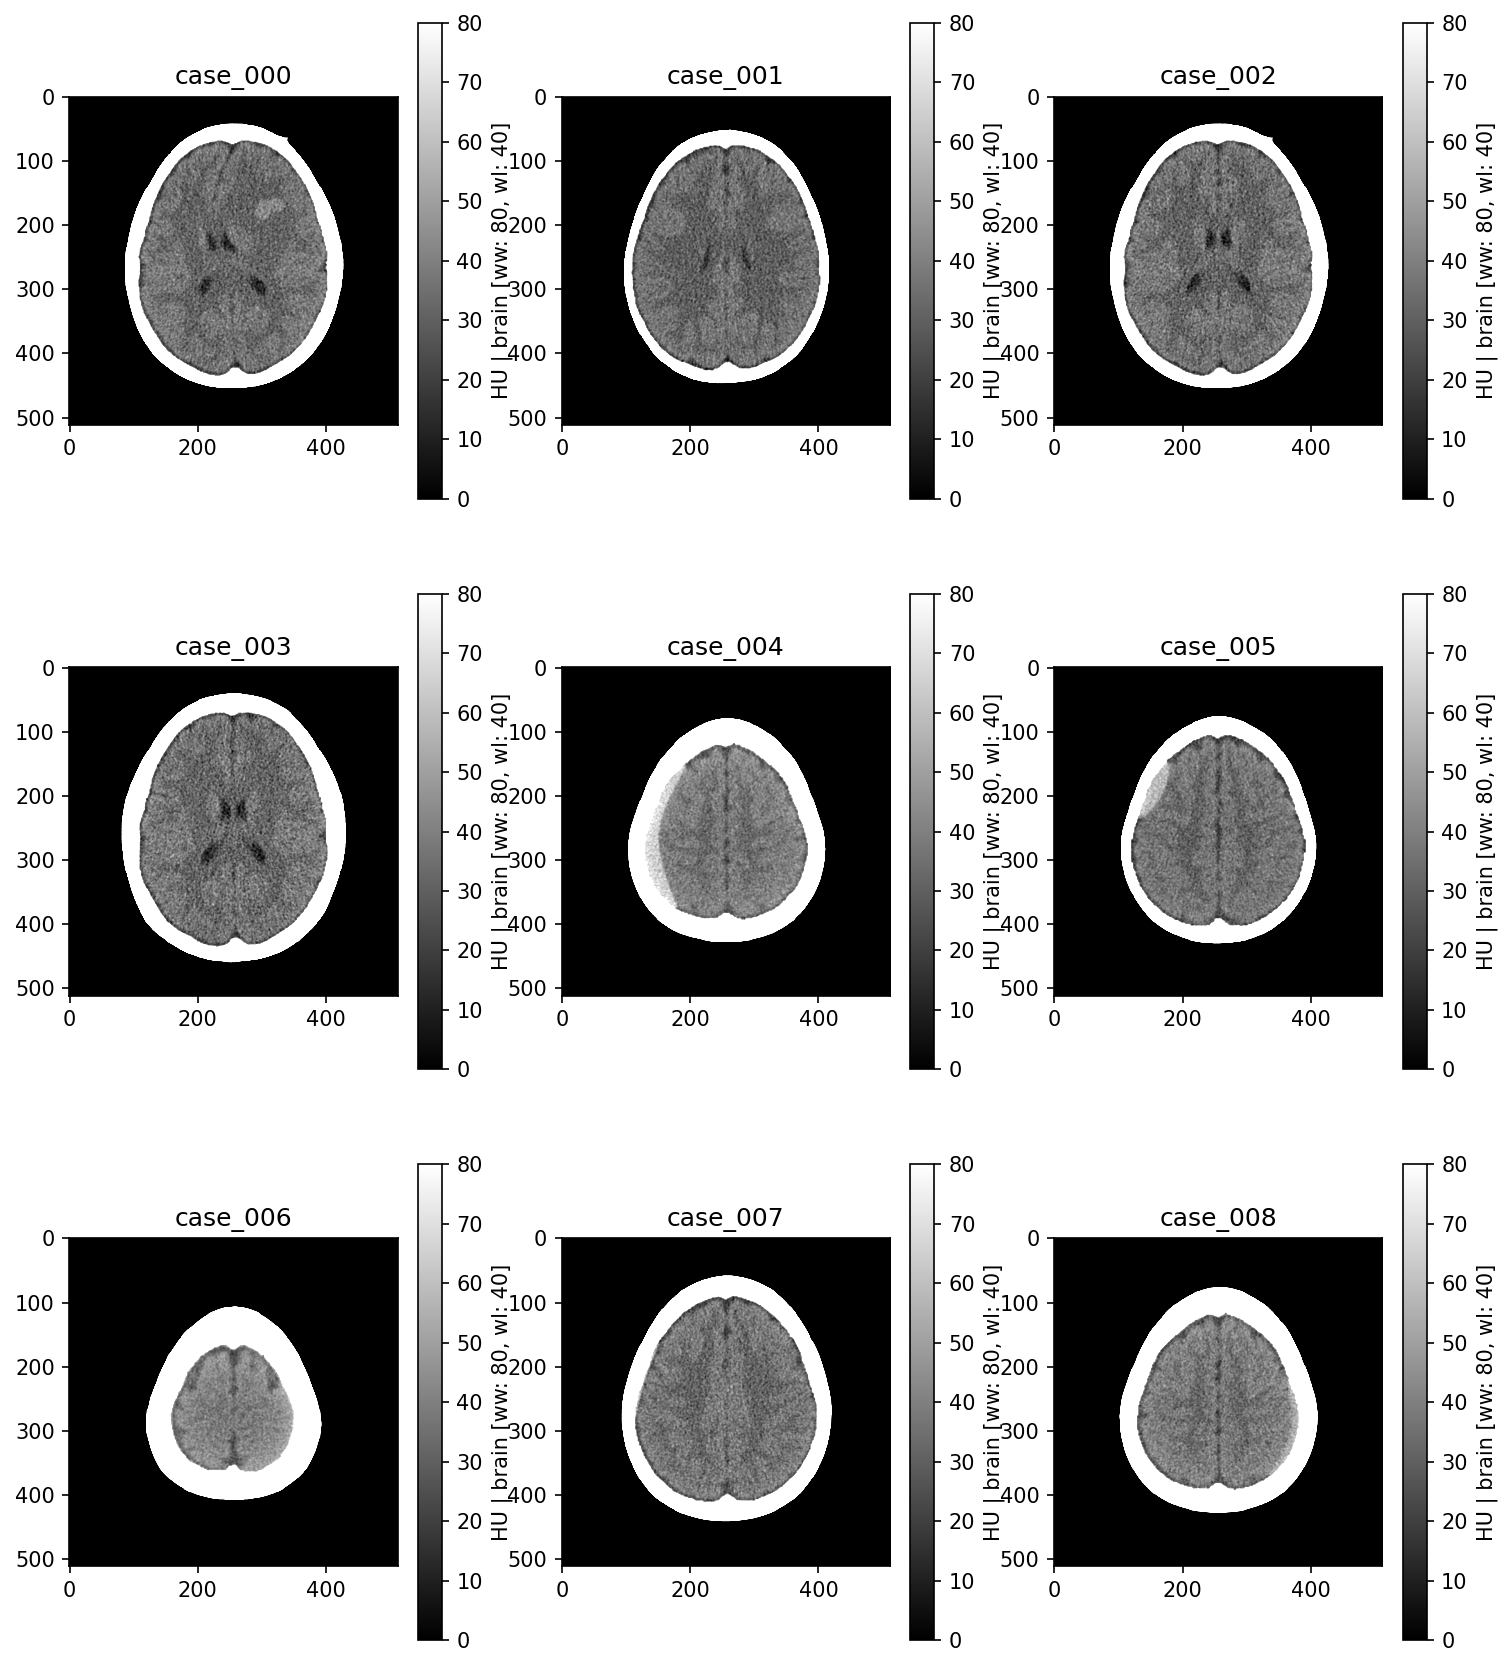

In [24]:
from matplotlib.patches import Rectangle 
nrows = 3
ncols = 3
f, axs = plt.subplots(nrows,ncols, figsize=(nrows*4,ncols*4+2), dpi=150)
for case, ax in zip(metadata['name'].unique(), axs.flatten()):
    if metadata[metadata['name'] == case]['mask file'].isna().iloc[0]:
        z = 10
    else:
        z, x, y = get_lesion_coords(load_vol(metadata[metadata['name'] == case]['mask file']))
    browse_studies(metadata, case, slice_idx=z, f=f, ax=ax, display='brain')
    # width = 3*metadata[metadata['name'] == case]['radius'].unique()[0]
    # ax.add_patch(Rectangle((x-width/2, y-width/2), width=width, height=width, fc ='none', ec ='g', lw = 1))

### Highlighting the lesion location with a segmentation mask overlay

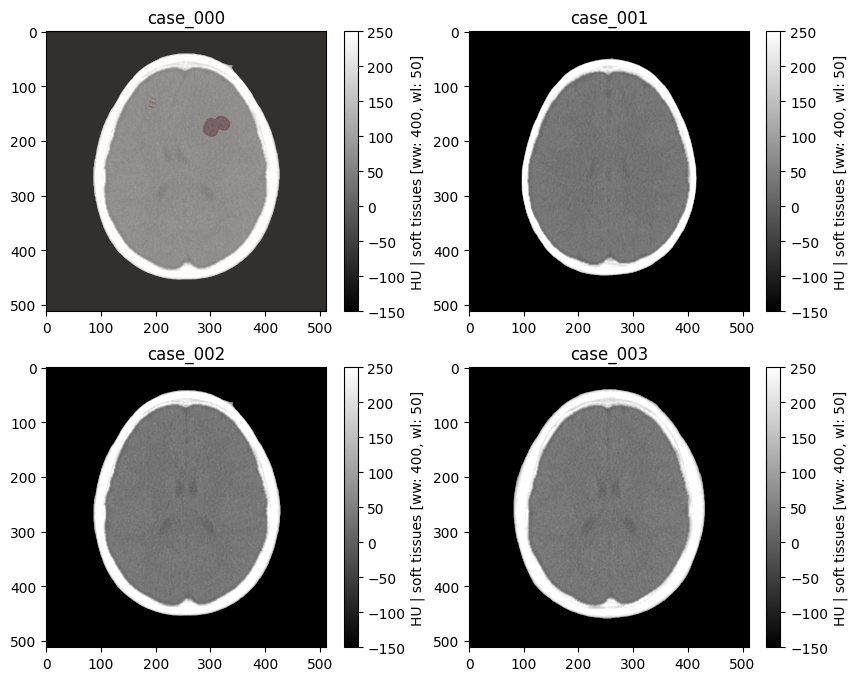

In [25]:
f, axs = plt.subplots(2,2, figsize=(10,8))
for case, ax in zip(metadata['name'].unique(), axs.flatten()):
    if not metadata[metadata['name'] == case]['mask file'].isna().iloc[0]:
        mask = load_vol(metadata[metadata['name'] == case]['mask file'])
        z, x, y = get_lesion_coords(mask)
    else:
         z = 10
    img = load_vol(metadata[metadata['name'] == case]['image file'])
    browse_studies(metadata, case, slice_idx=z, f=f, ax=ax)
    if not metadata[metadata['name'] == case]['mask file'].isna().iloc[0]:
        ax.imshow(mask[z] & (img[z]>-300), cmap='Reds', alpha=0.2)

## Reformated Views

In [26]:
from utils import scrollview
vol = load_vol(metadata[metadata['name']=='case_000']['image file'])

vol.shape

(23, 512, 512)

In [28]:
scrollview(vol, 'brain')

interactive(children=(IntSlider(value=11, description='idx', max=22), Output()), _dom_classes=('widget-interac…

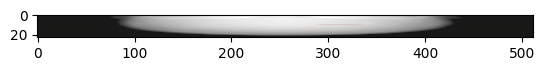

In [31]:
plt.imshow(vol.sum(axis=1), cmap='gray')
plt.imshow(mask.sum(axis=1), cmap='Reds', alpha=0.1)

In [32]:
metadata['lesion type'].unique()

array([nan, 'round', 'subdural', 'epidural'], dtype=object)

In [33]:
metadata[(metadata['lesion type'] == 'epidural')].sort_values(by='lesion volume [mL]')

,name,age,intensity,center x,center y,center z,lesion type,mass effect,lesion volume [mL],mA,kVp,views,fov [mm],kernel,image file,mask file,slice
866,case_042,6.50,64,177.0,183.0,14.0,epidural,0.000000,0.029104,300,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,17
1002,case_049,9.00,68,325.0,162.0,15.0,epidural,0.111111,0.033528,350,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,19
1725,case_086,12.00,61,178.0,319.0,14.0,epidural,0.000000,0.043772,350,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,19
934,case_045,15.75,67,283.0,150.0,14.0,epidural,0.777778,0.044121,300,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,19
646,case_031,15.75,31,144.0,225.0,14.0,epidural,0.555556,0.046217,300,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1921,case_097,10.50,52,296.0,206.0,17.0,epidural,0.000000,0.922359,350,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,17
1894,case_096,6.50,43,332.0,306.0,13.0,epidural,0.000000,1.029228,300,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,12
1895,case_096,6.50,43,332.0,306.0,13.0,epidural,0.000000,1.043896,300,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,13
1893,case_096,6.50,43,332.0,306.0,13.0,epidural,0.000000,1.081266,300,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,11


In [34]:
metadata[(metadata['lesion type'] == 'subdural')].sort_values(by='lesion volume [mL]')

,name,age,intensity,center x,center y,center z,lesion type,mass effect,lesion volume [mL],mA,kVp,views,fov [mm],kernel,image file,mask file,slice
290,case_012,15.75,37,145.0,319.0,14.0,subdural,0.777778,0.042841,300,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,18
1747,case_087,9.00,56,360.0,332.0,15.0,subdural,0.111111,0.054832,300,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,18
1249,case_062,9.00,42,288.0,361.0,15.0,subdural,0.000000,0.058906,300,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,19
534,case_025,15.75,61,271.0,151.0,15.0,subdural,0.555556,0.061351,300,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,19
578,case_027,12.00,48,351.0,205.0,16.0,subdural,0.333333,0.061467,300,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1611,case_081,9.00,55,276.0,166.0,13.0,subdural,0.888889,2.111541,300,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,11
1612,case_081,9.00,55,276.0,166.0,13.0,subdural,0.888889,2.112240,300,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,12
1261,case_063,15.75,49,246.0,348.0,12.0,subdural,0.777778,2.118642,300,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,10
1260,case_063,15.75,49,246.0,348.0,12.0,subdural,0.777778,2.140179,300,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,9


In [46]:
metadata[(metadata['lesion type'] == 'round')].sort_values(by='lesion volume [mL]')

,name,age,intensity,center x,center y,center z,lesion type,mass effect,lesion volume [mL],mA,kVp,views,fov [mm],kernel,image file,mask file,slice
660,case_032,12.00,59,308.0,289.0,10.0,round,0.777778,0.015600,350,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,10
350,case_016,9.00,54,343.0,190.0,9.0,round,0.666667,0.020023,350,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,9
11,case_000,12.00,43,172.0,305.0,10.0,round,1.000000,0.020489,350,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,11
1582,case_080,9.00,46,212.0,336.0,3.0,round,0.666667,0.024214,300,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,3
774,case_038,9.00,47,292.0,197.0,12.0,round,1.000000,0.038417,300,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,12
351,case_016,9.00,54,343.0,190.0,9.0,round,0.666667,0.042492,350,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,10
1627,case_082,6.50,47,112.0,261.0,6.0,round,0.555556,0.050757,350,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,6
259,case_011,15.75,34,191.0,301.0,11.0,round,0.333333,0.064843,350,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,10
727,case_035,11.50,42,305.0,258.0,11.0,round,0.444444,0.066822,350,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,11
1957,case_099,6.50,61,254.0,189.0,9.0,round,0.666667,0.066822,300,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,9


In [36]:
np.isnan(metadata['lesion type'].unique()[0])

np.True_

## Fig. 1 Plot Showing Dataset Labels 3 lesion types with masks

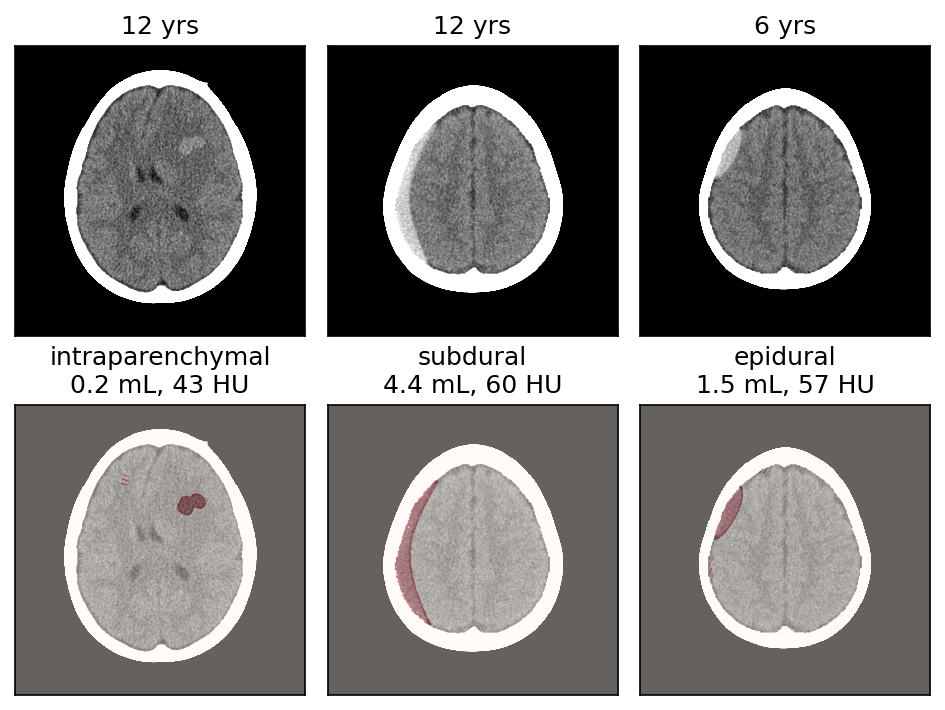

In [43]:
from utils import ctshow
window = 'brain'
cases = [metadata[metadata['lesion type'] == lesion]['name'].iloc[0] for lesion in metadata['lesion type'].unique() if \
         (len(metadata[metadata['lesion type'] == lesion]['name'])>0)]
f, axs = plt.subplots(2, len(cases), dpi=150, tight_layout=True)
if axs.ndim < 2:
    axs = axs[:, None]

for idx, case in enumerate(cases):
    z = metadata[(metadata['name'] == case) & (metadata['lesion volume [mL]']>0)]['center z'].iloc[0].astype(int)
    mask = read_dicom(metadata[(metadata['name'] == case) & (metadata['slice']==z)]['mask file'].item())
    img = read_dicom(metadata[(metadata['name'] == case) & (metadata['slice']==z)]['image file'].item())

    age =  metadata[metadata['name'] == case].iloc[z]['age'].astype(int)
    
    lesion_type = metadata[metadata['name'] == case].iloc[z]['lesion type']
    vol =  metadata[metadata['name'] == case]['lesion volume [mL]'].sum()
    intensity = metadata[metadata['name'] == case].iloc[z]['intensity']
    
    ctshow(img, fig=f, ax=axs[0, idx], window=window)
    axs[0, idx].set_title(f'{age} yrs')
    ctshow(img, fig=f, ax=axs[1, idx], window=window)
    axs[1, idx].imshow(mask & ((img > 0) & (img < 80)), cmap='Reds', alpha=0.4)
    if lesion_type == 'round':
        lesion_type = 'intraparenchymal'
    axs[1, idx].set_title(f'{lesion_type}\n{vol:2.1f} mL, {intensity} HU')

## Fig. 2 Plot Comparisons of Different kVp, mA, Recon Kernel

In [44]:
metadata[(~metadata['name'].duplicated())].sort_values(by='mA')

,name,age,intensity,center x,center y,center z,lesion type,mass effect,lesion volume [mL],mA,kVp,views,fov [mm],kernel,image file,mask file,slice
23,case_001,6.50,NaN,NaN,NaN,NaN,NaN,NaN,0.0,300,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,NaN,0
45,case_002,12.00,NaN,NaN,NaN,NaN,NaN,NaN,0.0,300,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,NaN,0
68,case_003,15.75,NaN,NaN,NaN,NaN,NaN,NaN,0.0,300,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,NaN,0
114,case_005,6.50,NaN,NaN,NaN,NaN,NaN,NaN,0.0,300,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,0
159,case_007,11.50,NaN,NaN,NaN,NaN,NaN,NaN,0.0,300,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1839,case_093,9.00,NaN,NaN,NaN,NaN,NaN,NaN,0.0,350,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,0
1859,case_094,12.00,NaN,NaN,NaN,NaN,NaN,NaN,0.0,350,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,0
1904,case_097,10.50,NaN,NaN,NaN,NaN,NaN,NaN,0.0,350,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,0
1796,case_091,10.50,NaN,NaN,NaN,NaN,NaN,NaN,0.0,350,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,0


In [45]:
metadata[(~metadata['name'].duplicated())].sort_values(by='kVp')

,name,age,intensity,center x,center y,center z,lesion type,mass effect,lesion volume [mL],mA,kVp,views,fov [mm],kernel,image file,mask file,slice
0,case_000,12.00,NaN,NaN,NaN,NaN,NaN,NaN,0.0,350,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,0
23,case_001,6.50,NaN,NaN,NaN,NaN,NaN,NaN,0.0,300,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,NaN,0
45,case_002,12.00,NaN,NaN,NaN,NaN,NaN,NaN,0.0,300,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,NaN,0
68,case_003,15.75,NaN,NaN,NaN,NaN,NaN,NaN,0.0,300,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,NaN,0
91,case_004,12.00,NaN,NaN,NaN,NaN,NaN,NaN,0.0,350,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1859,case_094,12.00,NaN,NaN,NaN,NaN,NaN,NaN,0.0,350,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,0
1882,case_096,6.50,NaN,NaN,NaN,NaN,NaN,NaN,0.0,300,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,0
1904,case_097,10.50,NaN,NaN,NaN,NaN,NaN,NaN,0.0,350,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,0
1925,case_098,11.50,NaN,NaN,NaN,NaN,NaN,NaN,0.0,350,120,1000,250,soft,/gpfs_projects/brandon.nelson/pedsilicoICH/ped...,NaN,0


## Fig 3. Pilot Study ROC curves with real and synthetic data